In [1]:
#Augmenting convnets with aggregated attention

In [2]:
import math
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras import ops
from tensorflow import data as tf_data

SEED = 42
keras.utils.set_random_seed(SEED)

In [3]:
BATCH_SIZE = 128
BUFFER_SIZE = BATCH_SIZE * 2
AUTO = tf_data.AUTOTUNE
INPUT_SHAPE = (32, 32, 3)
NUM_CLASSES = 10
IMAGE_SIZE = 48
DIMENSIONS = 256
SE_RATIO = 8
TRUNK_DEPTH = 2
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 50

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
(x_train, y_train), (x_val, y_val) = (
    (x_train[:40000], y_train[:40000]),
    (x_train[40000:], y_train[40000:]),
)
print(f"Training samples: {len(x_train)}")
print(f"Validation samples: {len(x_val)}")
print(f"Testing samples: {len(x_test)}")

train_ds = tf_data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(AUTO)

val_ds = tf_data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTO)

test_ds = tf_data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTO)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Training samples: 40000
Validation samples: 10000
Testing samples: 10000


In [5]:
def get_preprocessing():
    model = keras.Sequential(
        [
            layers.Rescaling(1 / 255.0),
            layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
        ],
        name="preprocessing",
    )
    return model


def get_train_augmentation_model():
    model = keras.Sequential(
        [
            layers.Rescaling(1 / 255.0),
            layers.Resizing(INPUT_SHAPE[0] + 20, INPUT_SHAPE[0] + 20),
            layers.RandomCrop(IMAGE_SIZE, IMAGE_SIZE),
            layers.RandomFlip("horizontal"),
        ],
        name="train_data_augmentation",
    )
    return model

In [6]:
def build_convolutional_stem(dimensions):

    config = {
        "kernel_size": (3, 3),
        "strides": (2, 2),
        "activation": ops.gelu,
        "padding": "same",
    }

    convolutional_stem = keras.Sequential(
        [
            layers.Conv2D(filters=dimensions // 2, **config),
            layers.Conv2D(filters=dimensions, **config),
        ],
        name="convolutional_stem",
    )

    return convolutional_stem

In [7]:
class SqueezeExcite(layers.Layer):


    def __init__(self, ratio, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

    def build(self, input_shape):
        filters = input_shape[-1]
        self.squeeze = layers.GlobalAveragePooling2D(keepdims=True)
        self.reduction = layers.Dense(
            units=filters // self.ratio,
            activation="relu",
            use_bias=False,
        )
        self.excite = layers.Dense(units=filters, activation="sigmoid", use_bias=False)
        self.multiply = layers.Multiply()

    def call(self, x):
        shortcut = x
        x = self.squeeze(x)
        x = self.reduction(x)
        x = self.excite(x)
        x = self.multiply([shortcut, x])
        return x


class Trunk(layers.Layer):


    def __init__(self, depth, dimensions, ratio, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
        self.dimensions = dimensions
        self.depth = depth

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "ratio": self.ratio,
                "dimensions": self.dimensions,
                "depth": self.depth,
            }
        )
        return config

    def build(self, input_shape):
        config = {
            "filters": self.dimensions,
            "activation": ops.gelu,
            "padding": "same",
        }

        trunk_block = [
            layers.LayerNormalization(epsilon=1e-6),
            layers.Conv2D(kernel_size=(1, 1), **config),
            layers.Conv2D(kernel_size=(3, 3), **config),
            SqueezeExcite(ratio=self.ratio),
            layers.Conv2D(kernel_size=(1, 1), filters=self.dimensions, padding="same"),
        ]

        self.trunk_blocks = [keras.Sequential(trunk_block) for _ in range(self.depth)]
        self.add = layers.Add()
        self.flatten_spatial = layers.Reshape((-1, self.dimensions))

    def call(self, x):
        # Remember the input.
        shortcut = x
        for trunk_block in self.trunk_blocks:
            output = trunk_block(x)
            shortcut = self.add([output, shortcut])
            x = shortcut
        # Flatten the patches.
        x = self.flatten_spatial(x)
        return x

In [8]:
class AttentionPooling(layers.Layer):


    def __init__(self, dimensions, num_classes, **kwargs):
        super().__init__(**kwargs)
        self.dimensions = dimensions
        self.num_classes = num_classes
        self.cls = keras.Variable(ops.zeros((1, 1, dimensions)))

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "dimensions": self.dimensions,
                "num_classes": self.num_classes,
                "cls": self.cls.numpy(),
            }
        )
        return config

    def build(self, input_shape):
        self.attention = layers.MultiHeadAttention(
            num_heads=1,
            key_dim=self.dimensions,
            dropout=0.2,
        )
        self.layer_norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential(
            [
                layers.Dense(units=self.dimensions, activation=ops.gelu),
                layers.Dropout(0.2),
                layers.Dense(units=self.dimensions, activation=ops.gelu),
            ]
        )
        self.dense = layers.Dense(units=self.num_classes)
        self.flatten = layers.Flatten()

    def call(self, x):
        batch_size = ops.shape(x)[0]

        class_token = ops.repeat(self.cls, repeats=batch_size, axis=0)

        x = ops.concatenate([class_token, x], axis=1)

        x = self.layer_norm1(x)
        x, viz_weights = self.attention(
            query=x[:, 0:1], key=x, value=x, return_attention_scores=True
        )
        class_token = class_token + x
        class_token = self.layer_norm2(class_token)
        class_token = self.flatten(class_token)
        class_token = self.layer_norm3(class_token)
        class_token = class_token + self.mlp(class_token)

        logits = self.dense(class_token)
        return logits, ops.squeeze(viz_weights)[..., 1:]

In [9]:
class PatchConvNet(keras.Model):
    def __init__(
        self,
        stem,
        trunk,
        attention_pooling,
        preprocessing_model,
        train_augmentation_model,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.stem = stem
        self.trunk = trunk
        self.attention_pooling = attention_pooling
        self.train_augmentation_model = train_augmentation_model
        self.preprocessing_model = preprocessing_model

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "stem": self.stem,
                "trunk": self.trunk,
                "attention_pooling": self.attention_pooling,
                "train_augmentation_model": self.train_augmentation_model,
                "preprocessing_model": self.preprocessing_model,
            }
        )
        return config

    def _calculate_loss(self, inputs, test=False):
        images, labels = inputs

        if test:
            augmented_images = self.preprocessing_model(images)
        else:
            augmented_images = self.train_augmentation_model(images)

        x = self.stem(augmented_images)

        x = self.trunk(x)

        logits, _ = self.attention_pooling(x)

        total_loss = self.compiled_loss(labels, logits)
        return total_loss, logits

    def train_step(self, inputs):
        with tf.GradientTape() as tape:
            total_loss, logits = self._calculate_loss(inputs)

        train_vars = [
            self.stem.trainable_variables,
            self.trunk.trainable_variables,
            self.attention_pooling.trainable_variables,
        ]
        grads = tape.gradient(total_loss, train_vars)
        trainable_variable_list = []
        for grad, var in zip(grads, train_vars):
            for g, v in zip(grad, var):
                trainable_variable_list.append((g, v))
        self.optimizer.apply_gradients(trainable_variable_list)

        _, labels = inputs
        self.compiled_metrics.update_state(labels, logits)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, inputs):
        total_loss, logits = self._calculate_loss(inputs, test=True)

        _, labels = inputs
        self.compiled_metrics.update_state(labels, logits)
        return {m.name: m.result() for m in self.metrics}

    def call(self, images):

        augmented_images = self.preprocessing_model(images)

        x = self.stem(augmented_images)

        x = self.trunk(x)

        logits, viz_weights = self.attention_pooling(x)
        return logits, viz_weights

In [10]:
test_images, test_labels = next(iter(test_ds))


class TrainMonitor(keras.callbacks.Callback):
    def __init__(self, epoch_interval=None):
        self.epoch_interval = epoch_interval

    def on_epoch_end(self, epoch, logs=None):
        if self.epoch_interval and epoch % self.epoch_interval == 4:
            test_augmented_images = self.model.preprocessing_model(test_images)

            test_x = self.model.stem(test_augmented_images)

            test_x = self.model.trunk(test_x)

            _, test_viz_weights = self.model.attention_pooling(test_x)

            num_patches = ops.shape(test_viz_weights)[-1]
            height = width = int(math.sqrt(num_patches))
            test_viz_weights = layers.Reshape((height, width))(test_viz_weights)

            index = np.random.randint(low=0, high=ops.shape(test_augmented_images)[0])
            selected_image = test_augmented_images[index]
            selected_weight = test_viz_weights[index]

            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
            ax[0].imshow(selected_image)
            ax[0].set_title(f"Original: {epoch:03d}")
            ax[0].axis("off")
            img = ax[1].imshow(selected_image)
            ax[1].imshow(
                selected_weight, cmap="inferno", alpha=0.6, extent=img.get_extent()
            )
            ax[1].set_title(f"Attended: {epoch:03d}")
            ax[1].axis("off")
            plt.axis("off")
            plt.show()
            plt.close()

In [11]:
class WarmUpCosine(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(
        self, learning_rate_base, total_steps, warmup_learning_rate, warmup_steps
    ):
        super().__init__()
        self.learning_rate_base = learning_rate_base
        self.total_steps = total_steps
        self.warmup_learning_rate = warmup_learning_rate
        self.warmup_steps = warmup_steps
        self.pi = np.pi

    def __call__(self, step):
        if self.total_steps < self.warmup_steps:
            raise ValueError("Total_steps must be larger or equal to warmup_steps.")
        cos_annealed_lr = ops.cos(
            self.pi
            * (ops.cast(step, "float32") - self.warmup_steps)
            / float(self.total_steps - self.warmup_steps)
        )
        learning_rate = 0.5 * self.learning_rate_base * (1 + cos_annealed_lr)
        if self.warmup_steps > 0:
            if self.learning_rate_base < self.warmup_learning_rate:
                raise ValueError(
                    "Learning_rate_base must be larger or equal to "
                    "warmup_learning_rate."
                )
            slope = (
                self.learning_rate_base - self.warmup_learning_rate
            ) / self.warmup_steps
            warmup_rate = slope * ops.cast(step, "float32") + self.warmup_learning_rate
            learning_rate = ops.where(
                step < self.warmup_steps, warmup_rate, learning_rate
            )
        return ops.where(
            step > self.total_steps,
            0.0,
            learning_rate,
        )


total_steps = int((len(x_train) / BATCH_SIZE) * EPOCHS)
warmup_epoch_percentage = 0.15
warmup_steps = int(total_steps * warmup_epoch_percentage)
scheduled_lrs = WarmUpCosine(
    learning_rate_base=LEARNING_RATE,
    total_steps=total_steps,
    warmup_learning_rate=0.0,
    warmup_steps=warmup_steps,
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:667: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:642: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 113ms/step - accuracy: 0.1831 - top-5-accuracy: 0.6632 - loss: 0.1262 - val_loss: 0.1174
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.3884 - top-5-accuracy: 0.8933 - loss: 0.0710 - val_loss: 0.0686
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.4812 - top-5-accuracy: 0.9295 - loss: 0.0224 - val_loss: 0.0322
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 111ms/step - accuracy: 0.5556 - top-5-accuracy: 0.9491 - loss: 0.0037 - val_loss: 0.0485
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6039 - top-5-accuracy: 0.9605 - loss: -0.0103

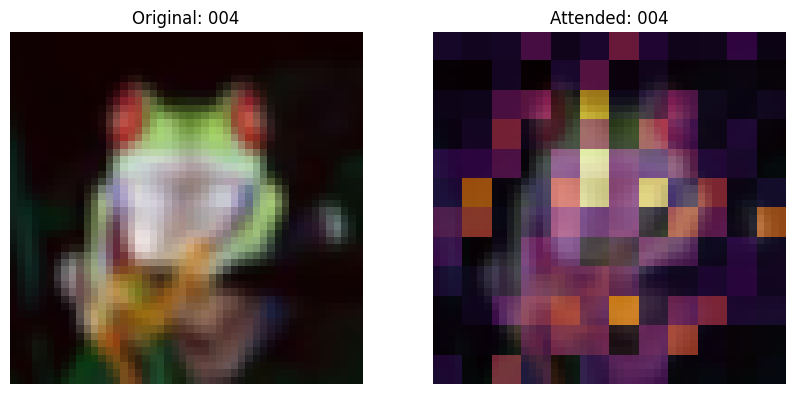

313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 119ms/step - accuracy: 0.6039 - top-5-accuracy: 0.9605 - loss: -0.0104 - val_loss: -0.0125
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 111ms/step - accuracy: 0.6454 - top-5-accuracy: 0.9684 - loss: -0.0456 - val_loss: -0.0471
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 111ms/step - accuracy: 0.6864 - top-5-accuracy: 0.9757 - loss: -0.0648 - val_loss: -0.0833
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.7084 - top-5-accuracy: 0.9774 - loss: -0.0929 - val_loss: -0.0693
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.7381 - top-5-accuracy: 0.9836 - loss: -0.0980 - val_loss: -0.1238
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7612 - top-5-accuracy: 0.9864 - loss: -0.0975

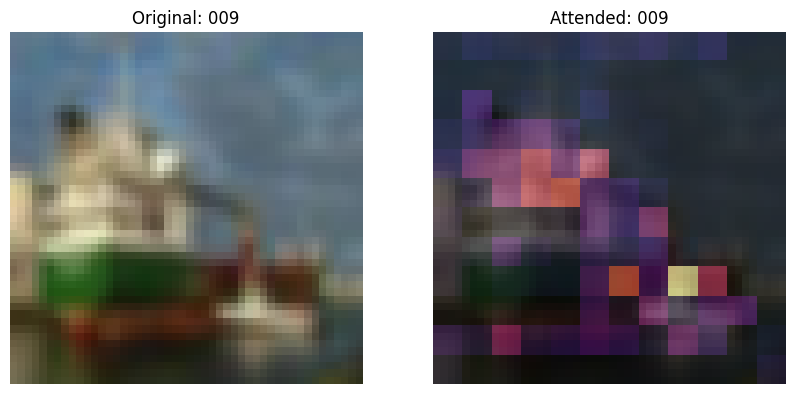

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.7612 - top-5-accuracy: 0.9864 - loss: -0.0975 - val_loss: -0.1606
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.7878 - top-5-accuracy: 0.9890 - loss: -0.1019 - val_loss: -0.1308
Epoch 12/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - accuracy: 0.7981 - top-5-accuracy: 0.9888 - loss: -0.1263 - val_loss: -0.1843
Epoch 13/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 123ms/step - accuracy: 0.8134 - top-5-accuracy: 0.9912 - loss: -0.1711 - val_loss: -0.1848
Epoch 14/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.8193 - top-5-accuracy: 0.9916 - loss: -0.1787 - val_loss: -0.1897
Epoch 15/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8317 - top-5-accuracy: 0.9929 - loss: -0.1561

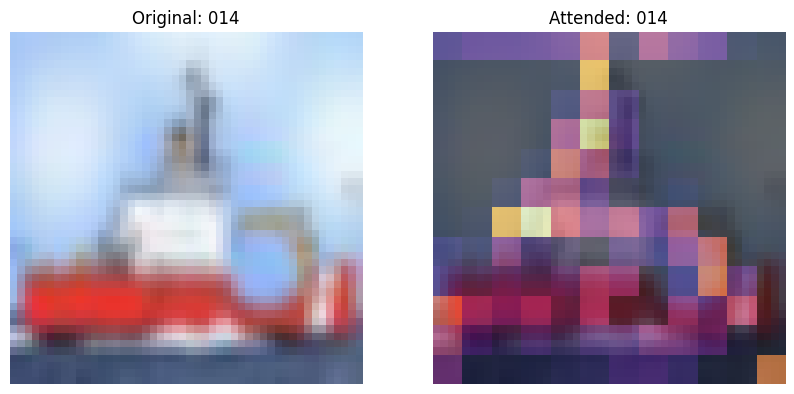

313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 122ms/step - accuracy: 0.8316 - top-5-accuracy: 0.9929 - loss: -0.1561 - val_loss: -0.1122
Epoch 16/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 114ms/step - accuracy: 0.8415 - top-5-accuracy: 0.9945 - loss: -0.1571 - val_loss: -0.2883
Epoch 17/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.8522 - top-5-accuracy: 0.9949 - loss: -0.2018 - val_loss: -0.1247
Epoch 18/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 112ms/step - accuracy: 0.8533 - top-5-accuracy: 0.9951 - loss: -0.2061 - val_loss: -0.1512
Epoch 19/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.8628 - top-5-accuracy: 0.9958 - loss: -0.1956 - val_loss: -0.2496
Epoch 20/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8668 - top-5-accuracy: 0.9954 - loss: -0.2099

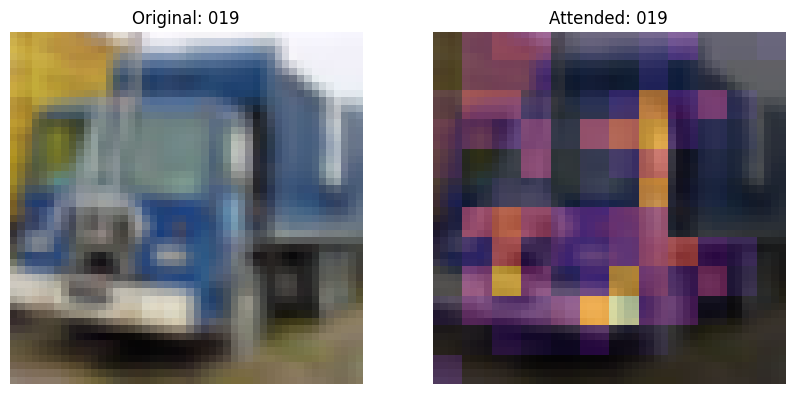

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.8666 - top-5-accuracy: 0.9954 - loss: -0.2099 - val_loss: -0.1710
Epoch 21/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.8746 - top-5-accuracy: 0.9963 - loss: -0.1918 - val_loss: -0.1328
Epoch 22/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.8841 - top-5-accuracy: 0.9974 - loss: -0.1787 - val_loss: -0.1924
Epoch 23/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.8934 - top-5-accuracy: 0.9976 - loss: -0.2201 - val_loss: -0.2066
Epoch 24/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.8997 - top-5-accuracy: 0.9984 - loss: -0.2206 - val_loss: -0.2594
Epoch 25/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9038 - top-5-accuracy: 0.9981 - loss: -0.1997

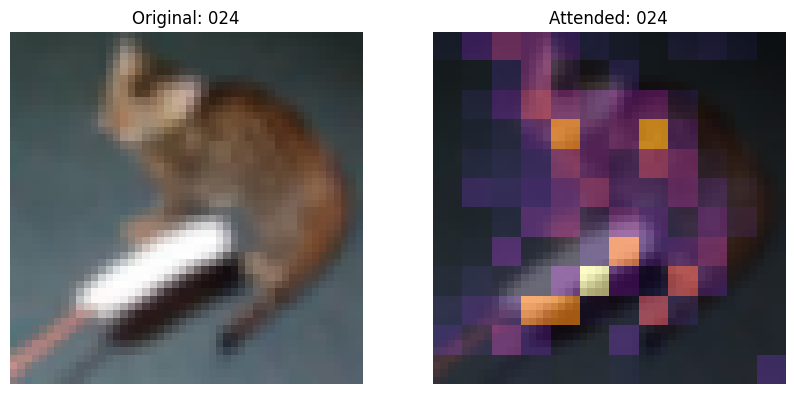

313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 113ms/step - accuracy: 0.9035 - top-5-accuracy: 0.9980 - loss: -0.1998 - val_loss: -0.2635
Epoch 26/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9094 - top-5-accuracy: 0.9982 - loss: -0.2110 - val_loss: -0.1573
Epoch 27/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 113ms/step - accuracy: 0.9195 - top-5-accuracy: 0.9988 - loss: -0.2314 - val_loss: -0.2454
Epoch 28/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9246 - top-5-accuracy: 0.9994 - loss: -0.2666 - val_loss: -0.3309
Epoch 29/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9313 - top-5-accuracy: 0.9992 - loss: -0.2717 - val_loss: -0.1884
Epoch 30/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9355 - top-5-accuracy: 0.9995 - loss: -0.2497

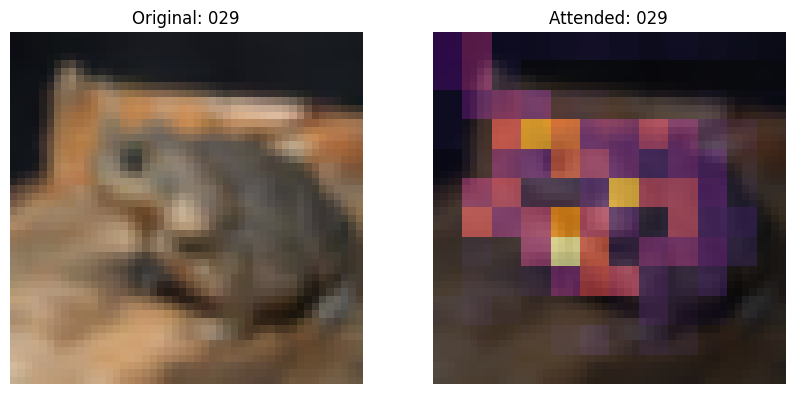

313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.9352 - top-5-accuracy: 0.9995 - loss: -0.2497 - val_loss: -0.2892
Epoch 31/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9401 - top-5-accuracy: 0.9995 - loss: -0.2021 - val_loss: -0.2357
Epoch 32/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.9442 - top-5-accuracy: 0.9995 - loss: -0.2471 - val_loss: -0.2390
Epoch 33/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.9507 - top-5-accuracy: 0.9997 - loss: -0.2247 - val_loss: -0.2536
Epoch 34/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9574 - top-5-accuracy: 0.9996 - loss: -0.2200 - val_loss: -0.2556
Epoch 35/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9612 - top-5-accuracy: 0.9997 - loss: -0.2279

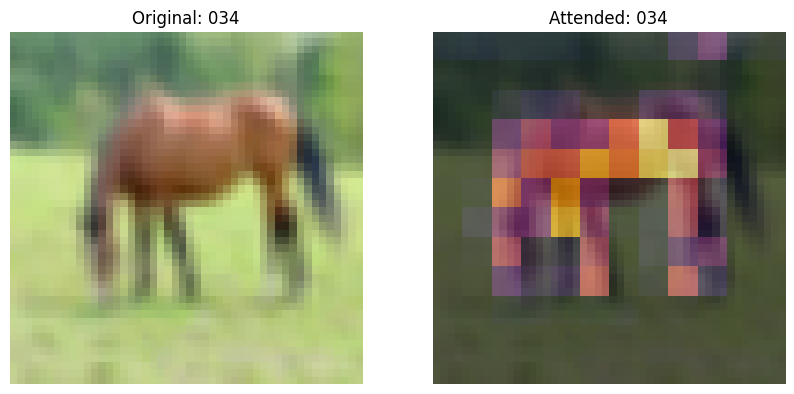

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9608 - top-5-accuracy: 0.9996 - loss: -0.2279 - val_loss: -0.2721
Epoch 36/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.9668 - top-5-accuracy: 1.0000 - loss: -0.1968 - val_loss: -0.2909
Epoch 37/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.9685 - top-5-accuracy: 0.9999 - loss: -0.2244 - val_loss: -0.2874
Epoch 38/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.9715 - top-5-accuracy: 0.9999 - loss: -0.2333 - val_loss: -0.2668
Epoch 39/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9771 - top-5-accuracy: 0.9999 - loss: -0.2342 - val_loss: -0.1974
Epoch 40/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9785 - top-5-accuracy: 1.0000 - loss: -0.2021

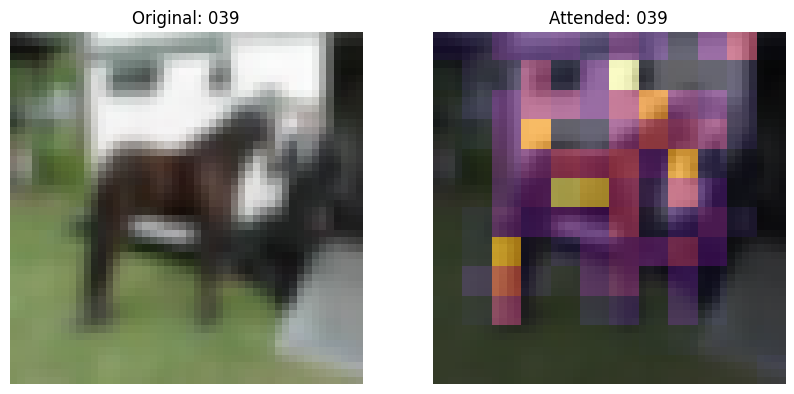

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.9782 - top-5-accuracy: 1.0000 - loss: -0.2020 - val_loss: -0.1782
Epoch 41/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - accuracy: 0.9829 - top-5-accuracy: 0.9999 - loss: -0.1586 - val_loss: -0.1904
Epoch 42/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.9852 - top-5-accuracy: 1.0000 - loss: -0.1675 - val_loss: -0.1448
Epoch 43/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.9869 - top-5-accuracy: 1.0000 - loss: -0.1663 - val_loss: -0.1763
Epoch 44/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.9880 - top-5-accuracy: 1.0000 - loss: -0.1712 - val_loss: -0.1710
Epoch 45/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9897 - top-5-accuracy: 1.0000 - loss: -0.1640

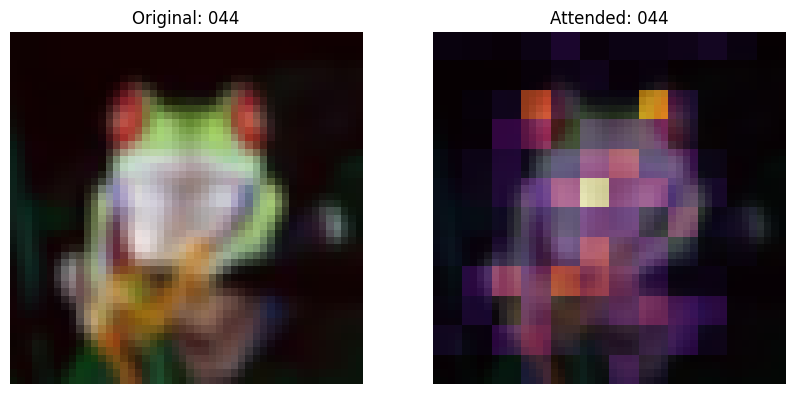

313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.9893 - top-5-accuracy: 1.0000 - loss: -0.1640 - val_loss: -0.1537
Epoch 46/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.9914 - top-5-accuracy: 1.0000 - loss: -0.1385 - val_loss: -0.1484
Epoch 47/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - accuracy: 0.9924 - top-5-accuracy: 1.0000 - loss: -0.1523 - val_loss: -0.1607
Epoch 48/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.9930 - top-5-accuracy: 1.0000 - loss: -0.1457 - val_loss: -0.1498
Epoch 49/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.9935 - top-5-accuracy: 1.0000 - loss: -0.1430 - val_loss: -0.1300
Epoch 50/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9935 - top-5-accuracy: 1.0000 - loss: -0.1350

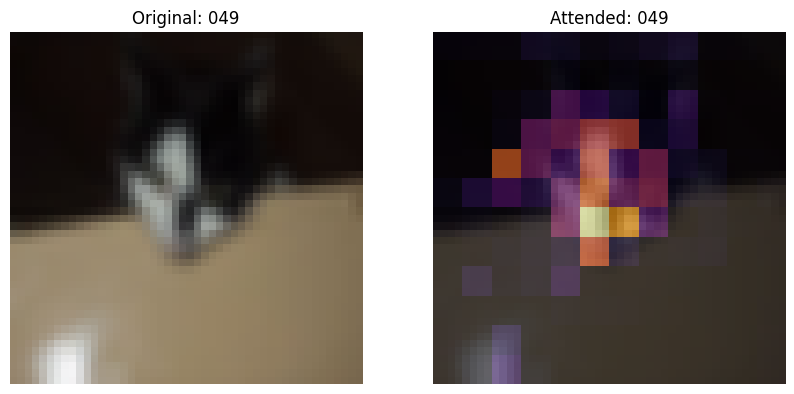

313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.9931 - top-5-accuracy: 1.0000 - loss: -0.1349 - val_loss: -0.1291
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8591 - top-5-accuracy: 0.9939 - loss: -0.1344


ValueError: not enough values to unpack (expected 3, got 2)

In [12]:
train_augmentation_model = get_train_augmentation_model()
preprocessing_model = get_preprocessing()
conv_stem = build_convolutional_stem(dimensions=DIMENSIONS)
conv_trunk = Trunk(depth=TRUNK_DEPTH, dimensions=DIMENSIONS, ratio=SE_RATIO)
attention_pooling = AttentionPooling(dimensions=DIMENSIONS, num_classes=NUM_CLASSES)

patch_conv_net = PatchConvNet(
    stem=conv_stem,
    trunk=conv_trunk,
    attention_pooling=attention_pooling,
    train_augmentation_model=train_augmentation_model,
    preprocessing_model=preprocessing_model,
)


train_callbacks = [TrainMonitor(epoch_interval=5)]

optimizer = keras.optimizers.AdamW(
    learning_rate=scheduled_lrs, weight_decay=WEIGHT_DECAY
)

patch_conv_net.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
    ],
)
history = patch_conv_net.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=train_callbacks,
)


loss, acc_top1, acc_top5 = patch_conv_net.evaluate(test_ds)
print(f"Loss: {loss:0.2f}")
print(f"Top 1 test accuracy: {acc_top1*100:0.2f}%")
print(f"Top 5 test accuracy: {acc_top5*100:0.2f}%")

In [32]:
def plot_attention(image):


    image = ops.image.resize(image, (224, 224))
    image = image[np.newaxis, ...]
    test_augmented_images = patch_conv_net.preprocessing_model(image)

    test_x = patch_conv_net.stem(test_augmented_images)

    test_x = patch_conv_net.trunk(test_x)

    _, test_viz_weights = patch_conv_net.attention_pooling(test_x)
    test_viz_weights = test_viz_weights[np.newaxis, ...]

    num_patches = ops.shape(test_viz_weights)[-1]
    height = width = int(math.sqrt(num_patches))
    test_viz_weights = layers.Reshape((height, width))(test_viz_weights)
    selected_image = test_augmented_images[0]
    selected_weight = test_viz_weights[0]

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    ax[0].imshow(selected_image)
    ax[0].set_title(f"Original")
    ax[0].axis("off")
    img = ax[1].imshow(selected_image)
    ax[1].imshow(selected_weight, cmap="inferno", alpha=0.6, extent=img.get_extent())
    ax[1].set_title(f"Attention")
    ax[1].axis("off")
    plt.axis("off")
    plt.show()
    plt.close()




Saving images (4).jpeg to images (4) (3).jpeg


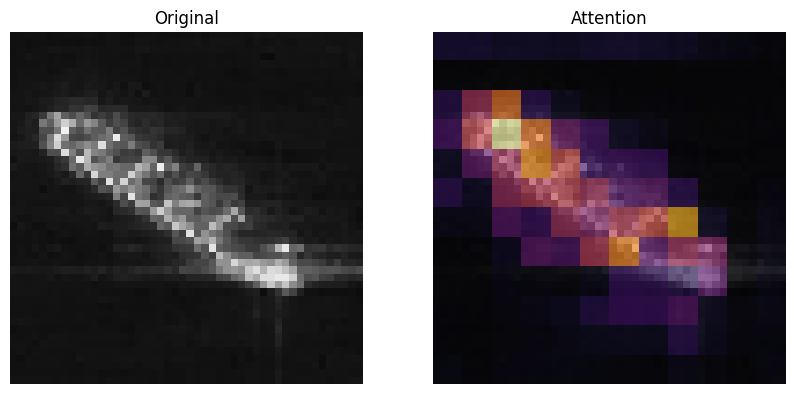

In [29]:
"""
from tensorflow import keras
from IPython.display import display
from PIL import Image
import numpy as np
from google.colab import files

# Upload and load image
uploaded = files.upload()  # Opens file dialog
file_name = next(iter(uploaded))  # Gets uploaded filename

image = keras.utils.load_img(file_name, target_size=(224, 224))
image = keras.utils.img_to_array(image)


plot_attention(image)

"""

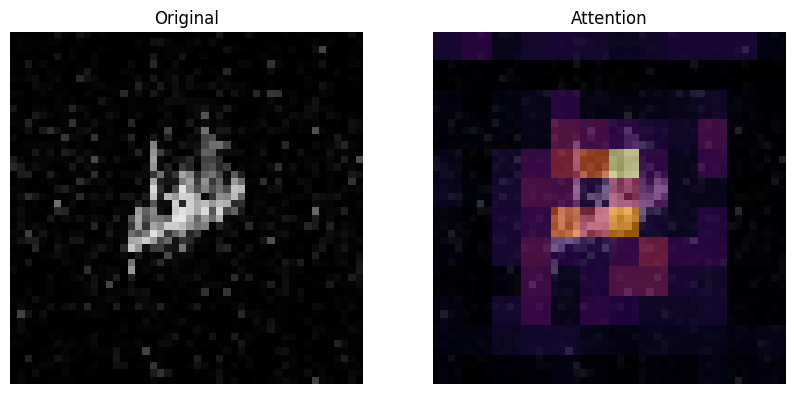

In [35]:
import numpy as np
import os
image_path = "/content/images (3) (2).jpeg"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)